Pranay's contribution

LLM Prompts:


*   how to preprocess my tweets data for Non-causal Transformer model using embedding layer with position embeddings
*   use this image as the reference and give me the step by step procedure to preprocess
*   ...
*   help me  build a Non-causal Transformer model using embedding layer with position embeddings with a step by step explaination
*   what more i can do to the data to improve the validation accuracy.





Non-causal Transformer model using embedding layer with position embeddings

In [2]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv')

# Show column names
print("Columns in the dataset:", train_df.columns.tolist())

# Peek at the first few rows
print(train_df.head())


Columns in the dataset: ['Tweet', 'Sentiment', 'cleaned_text', 'sentiment_simple']
                                               Tweet   Sentiment  \
0  Trust Nothing the Media Focuses on when ever t...  Strong_Pos   
1  @SageFrancis I know some people are pulling of...  Strong_Pos   
2  they "brought violence upon themselves". Trans...  Strong_Neg   
3  ÃÂÃÂ°ÃÂÃÂÃÂÃÂÃÂÃÂºÃÂÃÂ°ÃÂÃ...     Neutral   
4  Freedom Convoy protesters describe interaction...  Strong_Pos   

                                        cleaned_text sentiment_simple  
0  trust nothing the media focuses on when ever t...         Positive  
1  i know some people are pulling off of patreon ...         Positive  
2  they brought violence upon themselves translat...         Negative  
3          freedom convoy 2 thousand trucks long via          Neutral  
4  freedom convoy protesters describe interaction...         Positive  


In [3]:
print(train_df['sentiment_simple'].value_counts())


sentiment_simple
Positive    14008
Negative    14008
Neutral     14008
Name: count, dtype: int64


In [7]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_df['cleaned_text'] = train_df['cleaned_text'].fillna("")
val_df['cleaned_text'] = val_df['cleaned_text'].fillna("")
test_df['cleaned_text'] = test_df['cleaned_text'].fillna("")


# Define parameters
MAX_VOCAB_SIZE = 10000
MAX_LEN = 128

# Initialize and fit tokenizer on train only
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['cleaned_text'])

def preprocess_text(df):
    sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
    padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
    return padded

# Tokenize and pad sequences
X_train = preprocess_text(train_df)
X_val = preprocess_text(val_df)
X_test = preprocess_text(test_df)

# Map labels to integers
label_map = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
y_train = train_df['sentiment_simple'].map(label_map).values
y_val = val_df['sentiment_simple'].map(label_map).values
y_test = test_df['sentiment_simple'].map(label_map).values

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (42024, 128) (42024,)
Val shape: (8976, 128) (8976,)
Test shape: (9000, 128) (9000,)


In [10]:
import tensorflow as tf
from tensorflow.keras import layers

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

def build_model():
    embed_dim = 64
    num_heads = 4
    ff_dim = 128
    num_classes = 3
    maxlen = 128
    vocab_size = 10000

    inputs = layers.Input(shape=(maxlen,))
    x = PositionalEmbedding(maxlen, vocab_size, embed_dim)(inputs)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Explicitly set all layers trainable
    for layer in model.layers:
        layer.trainable = True

    return model

model = build_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_1          │ (None, 128, 64)        │       648,192 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 735,747 (2.81 MB)

 Trainable params: 735,747 (2.81 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)


Epoch 1/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.4923 - loss: 0.9814 - val_accuracy: 0.7000 - val_loss: 0.6957
Epoch 2/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7346 - loss: 0.6242 - val_accuracy: 0.7115 - val_loss: 0.6671
Epoch 3/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7754 - loss: 0.5343 - val_accuracy: 0.7132 - val_loss: 0.6901
Epoch 4/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7996 - loss: 0.4788 - val_accuracy: 0.7141 - val_loss: 0.6897
Epoch 5/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8195 - loss: 0.4309 - val_accuracy: 0.7059 - val_loss: 0.7806
Epoch 6/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8459 - loss: 0.3706 - val_accuracy: 0.7004 - val_loss: 0.8882
Epoch 7/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8680 - loss: 0.3224 - val_accuracy: 0.7068 - val_loss: 0.9323
Epoch 8/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8899 - loss: 0.27

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.3):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

def build_model():
    embed_dim = 64
    num_heads = 4
    ff_dim = 128
    num_classes = 3
    maxlen = 128
    vocab_size = 10000

    inputs = layers.Input(shape=(maxlen,))
    x = PositionalEmbedding(maxlen, vocab_size, embed_dim)(inputs)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)  # 2nd block
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

model = build_model()

optimizer = optimizers.Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Early stopping callback
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training (example)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_2          │ (None, 128, 64)        │       648,192 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818,947 (3.12 MB)

 Trainable params: 818,947 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.3979 - loss: 1.0849 - val_accuracy: 0.5995 - val_loss: 0.8670
Epoch 2/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.6394 - loss: 0.8106 - val_accuracy: 0.6927 - val_loss: 0.7054
Epoch 3/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7218 - loss: 0.6537 - val_accuracy: 0.7011 - val_loss: 0.7113
Epoch 4/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7581 - loss: 0.5769 - val_accuracy: 0.7100 - val_loss: 0.7038
Epoch 5/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.7879 - loss: 0.5175 - val_accuracy: 0.7120 - val_loss: 0.7207
Epoch 6/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8039 - loss: 0.4778 - val_accuracy: 0.7061 - val_loss: 0.7412
Epoch 7/20
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8225 - loss: 0.4398 - val_accuracy: 0.7010 - val_loss: 0.8602


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.4):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

def build_model():
    embed_dim = 64
    num_heads = 4
    ff_dim = 128
    num_classes = 3
    maxlen = 128
    vocab_size = 10000

    inputs = layers.Input(shape=(maxlen,))
    x = PositionalEmbedding(maxlen, vocab_size, embed_dim)(inputs)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)  # 3rd block
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

model = build_model()

# Adam optimizer with gradient clipping
optimizer = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_1          │ (None, 128, 64)        │       648,192 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 128, 64)        │        83,200 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902,147 (3.44 MB)

 Trainable params: 902,147 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.3983 - loss: 1.0990 - val_accuracy: 0.6083 - val_loss: 0.8759 - learning_rate: 1.0000e-04
Epoch 2/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6171 - loss: 0.8557 - val_accuracy: 0.6647 - val_loss: 0.7954 - learning_rate: 1.0000e-04
Epoch 3/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6970 - loss: 0.7136 - val_accuracy: 0.7030 - val_loss: 0.7351 - learning_rate: 1.0000e-04
Epoch 4/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7390 - loss: 0.6286 - val_accuracy: 0.6975 - val_loss: 0.7888 - learning_rate: 1.0000e-04
Epoch 5/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7710 - loss: 0.5631 - val_accuracy: 0.7120 - val_loss: 0.7838 - learning_rate: 1.0000e-04
Epoch 6/30
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.7941 - loss: 0.5120 - val_accuracy: 0.7021 - val_loss: 0.8601 - learning_rate: 5.0000e-05
Epoch 7/30
1314/1314 ━━━━━━━━━━━━━━━━━━━

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7013 - loss: 0.7412
Test Loss: 0.7392
Test Accuracy: 0.7010


In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      3000
           1       0.66      0.81      0.73      3000
           2       0.70      0.56      0.63      3000

    accuracy                           0.70      9000
   macro avg       0.70      0.70      0.70      9000
weighted avg       0.70      0.70      0.70      9000

Confusion Matrix:
[[2199  411  390]
 [ 260 2417  323]
 [ 478  829 1693]]


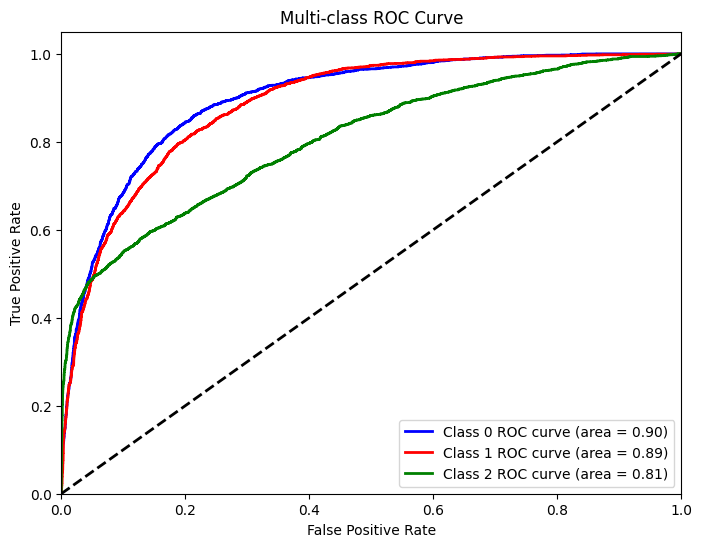

In [21]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} ROC curve (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()
